In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV, KFold

In [2]:
dior = pd.read_csv("dior_clean.csv")
dior = dior[dior["product_subcategory_Accessories"] == True] #I only select the category of accessories; I get rid of columns that became useless
dior = dior.drop(columns=[c for c in dior.columns if c.startswith("product_subcategory_")])
dior = dior.loc[:, dior.nunique() > 1]
dior.corr(numeric_only=True)["is_return"].sort_values(ascending=False) 
#If there is an irrealistic correlation, it would indicate some dataleakage (That is why I got rid off timespan_days_less_than_10)

is_return                      1.000000
sales_band_500_2000            0.107595
shipping address - state_WY    0.063062
quantity_0.0                   0.038671
shipping address - state_IL    0.028612
                                 ...   
is exchange                   -0.069593
csc commercial gestures       -0.089456
sales_band_0_500              -0.108870
is_ltsourcing                 -0.161282
timespan_days_less_than_10    -0.989414
Name: is_return, Length: 82, dtype: float64

In [3]:
#We prepare the data (getting rid of dangerous correlations), split it into train and test and prepare the cross validation
X, y = dior.drop(columns=["order number", "order status", "is_return", "timespan_days_less_than_10"]), dior["is_return"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, 
                                            shuffle=True, random_state=72)
cv = KFold(n_splits=3, shuffle=True, random_state=72)

In [4]:
#Test 1: Use Naive Bayes
nbc = GaussianNB()

nbc.fit(X_train, y_train)

y_pred_train_bayes = nbc.predict(X_train)
y_pred_test_bayes = nbc.predict(X_test)
p_nbc_test = nbc.predict_proba(X_test)[:, 1]

print(f"Accuracy test Bayes: {accuracy_score(y_test, y_pred_test_bayes):.5f}")
print(f"Accuracy train Bayes: {accuracy_score(y_train, y_pred_train_bayes):.5f}")
#The results seem to be very bad. This can be explained that 
# Explanation: Naive Bayes performs poorly here because many features (like the US states) are highly correlated, which breaks the model's independence assumption.

Accuracy test Bayes: 0.40259
Accuracy train Bayes: 0.40643


In [5]:
#Test 2: Use Classifier which always predicts the most common class

# What is the most common class?
display(  round( y_train.value_counts()/dior.shape[0], 3   ))

# So we predict always zero for the "most-common" classifier
y_pred_train_mc = np.zeros(len(y_train))
y_pred_test_mc = np.zeros(len(y_test))


print(f"Accuracy test Most Common: {accuracy_score(y_test, y_pred_test_mc):.5f}")
print(f"Accuracy train Most Common: {accuracy_score(y_train, y_pred_train_mc):.5f}")
#It points out how bad our naïve Bayes classifier ist

is_return
0    0.477
1    0.223
Name: count, dtype: float64

Accuracy test Most Common: 0.68502
Accuracy train Most Common: 0.68189


In [6]:
#Test 3: Use Logistic Regression
lrc = LogisticRegression(max_iter=5000, penalty = None)

lrc.fit(X_train, y_train)

y_pred_train_lrc = lrc.predict(X_train)
y_pred_test_lrc = lrc.predict(X_test)
p_lrc_test = lrc.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg: {accuracy_score(y_test, y_pred_test_lrc):.5f}")
print(f"Accuracy train Logreg: {accuracy_score(y_train, y_pred_train_lrc):.5f}")

# It manages to converge with a not too bad accuracy performance

Accuracy test Logreg: 0.69551
Accuracy train Logreg: 0.69359


In [7]:
#Test 4: Use Logistic Regression with lasso penalization as we could notice some overfitting in the logistic regression
lrc_lasso = LogisticRegression(penalty="l1", solver="liblinear", max_iter=1000, random_state=72)

lrc_lasso.fit(X_train, y_train)

y_pred_train_lrc_lasso = lrc_lasso.predict(X_train)
y_pred_test_lrc_lasso = lrc_lasso.predict(X_test)
p_lrc_lasso_test = lrc_lasso.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg (lasso): {accuracy_score(y_test, y_pred_test_lrc_lasso):.5f}")
print(f"Accuracy train Logreg (lasso): {accuracy_score(y_train, y_pred_train_lrc_lasso):.5f}")
#It does not make a huge difference but the model still performs better in the test set

Accuracy test Logreg (lasso): 0.69567
Accuracy train Logreg (lasso): 0.69307


In [8]:
#Test 5: Use Logistic Regression with Ridge penalization to see if it works better than Lasso
lrc_ridge = LogisticRegression(penalty="l2", max_iter=5000)

lrc_ridge.fit(X_train, y_train)

y_pred_train_lrc_ridge = lrc_ridge.predict(X_train)
y_pred_test_lrc_ridge = lrc_ridge.predict(X_test)
p_lrc_ridge_test = lrc_ridge.predict_proba(X_test)[:, 1]

print(f"Accuracy test Logreg (ridge): {accuracy_score(y_test, y_pred_test_lrc_ridge):.5f}")
print(f"Accuracy train Logreg (ridge): {accuracy_score(y_train, y_pred_train_lrc_ridge):.5f}")

Accuracy test Logreg (ridge): 0.69567
Accuracy train Logreg (ridge): 0.69359


In [9]:
#Test 6: Neural Network
from sklearn.neural_network import MLPClassifier
nnet = MLPClassifier(hidden_layer_sizes=(8, 16, 8),
                     learning_rate_init=0.003,
                     activation="relu",
                     solver="sgd", 
                     alpha=0.001,
                     batch_size=32,
                     max_iter=500, random_state = 72)
nnet.fit(X_train, y_train)

y_pred_train_neuron = nnet.predict(X_train)
y_pred_test_neuron = nnet.predict(X_test)
p_neuron_test = nnet.predict_proba(X_test)[:, 1]

print(f"Accuracy test Neural Network: {accuracy_score(y_test, y_pred_test_neuron):.5f}")
print(f"Accuracy train Neural Network: {accuracy_score(y_train, y_pred_train_neuron):.5f}")
#The model seems to perform better a bit better than logistic regression; let us tune the hyperparameter using Cross Validation

Accuracy test Neural Network: 0.67947
Accuracy train Neural Network: 0.70014


In [5]:
#Test 7: Random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=300, 
                            max_depth=20, 
                            min_samples_split=2, 
                            min_samples_leaf=1, 
                            max_features="sqrt", 
                            random_state=72 ) 
rf.fit(X_train, y_train) 

y_pred_test_rf = rf.predict(X_test) 
y_pred_train_rf = rf.predict(X_train)
p_rf_test = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy test Random Forest: {accuracy_score(y_test, y_pred_test_rf):.5f}")
print(f"Accuracy train Random Forest: {accuracy_score(y_train, y_pred_train_rf):.5f}")

Accuracy test Random Forest: 0.69505
Accuracy train Random Forest: 0.70926


In [6]:
#Test 8: Random forest with tuned hyperparameters using cross-validation
from sklearn.ensemble import RandomForestClassifier

param_distributions = {
    "n_estimators": [150, 300],
    "min_samples_split": [2, 3],
    "max_depth": [10, 20],           
    "min_samples_leaf": [1, 2, 5],
    "max_features": ["sqrt"]}

search = RandomizedSearchCV(
    RandomForestClassifier(random_state=72),
    param_distributions=param_distributions,
    scoring="accuracy",
    cv=cv,
    refit=True,   # refit best on all training data
    return_train_score=True, random_state = 72)



search.fit(X_train, y_train)
best_model = search.best_estimator_
y_pred_test_rf_hyp = best_model.predict(X_test)
y_pred_train_rf_hyp = best_model.predict(X_train)
p_rf_hyp_test = search.predict_proba(X_test)[:, 1]
print(f"Accuracy test Random Forest with hyperparameter tunning: {accuracy_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Accuracy train Random Forest with hyperparameter tunning: {accuracy_score(y_train, y_pred_train_rf_hyp):.3f}")

Accuracy test Random Forest with hyperparameter tunning: 0.695
Accuracy train Random Forest with hyperparameter tunning: 0.702


In [12]:
#Test 9: Boosting
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_leaf_nodes=30,
    min_samples_leaf=20,
    early_stopping=True,
    n_iter_no_change=20,
    validation_fraction=0.2,
    random_state=72,
    verbose=0
)
gb.fit(X_train, y_train)
y_pred_test_boosting = gb.predict(X_test)
y_pred_train_boosting = gb.predict(X_train)
p_boosting_test = gb.predict_proba(X_test)[:, 1]
print(f"Accuracy test Boosting: {accuracy_score(y_test, y_pred_test_boosting):.5f}")
print(f"Accuracy test Boosting: {accuracy_score(y_train, y_pred_train_boosting):.5f}")

Accuracy test Boosting: 0.69243
Accuracy test Boosting: 0.69472


In [13]:
#Test 10: Boosting with tuned hyperparameters using cross validation

param_dist = {
    "learning_rate": [0.05, 0.5],
    "max_leaf_nodes": [20, 30, 35],
    "min_samples_leaf": [10, 20],
    "n_iter_no_change": [10, 20, 30]
}

search_boosting = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        early_stopping=True,
        validation_fraction=0.2,
        random_state=72
    ),
    param_distributions=param_dist,              
    scoring="accuracy",
    cv=cv,
    random_state=72
)
search_boosting.fit(X_train, y_train)
best_model_boosting = search_boosting.best_estimator_
y_pred_test_boosting_hyp = best_model_boosting.predict(X_test)
y_pred_train_boosting_hyp = best_model_boosting.predict (X_train)
p_boosting_hyp_test = best_model_boosting.predict_proba(X_test)[:, 1]

print(f"Accuracy test Boosting with tuned hyperparameters: {accuracy_score(y_test, y_pred_test_boosting_hyp):.3f}")
print(f"Accuracy train Boosting with tuned hyperparameters: {accuracy_score(y_train, y_pred_train_boosting_hyp):.3f}")

Accuracy test Boosting with tuned hyperparameters: 0.695
Accuracy train Boosting with tuned hyperparameters: 0.697


In [14]:
from sklearn.metrics import accuracy_score

print(f"Accuracy test Bayes: {accuracy_score(y_test, y_pred_test_bayes):.3f}")
print(f"Accuracy test Most Common: {accuracy_score(y_test, y_pred_test_mc):.3f}")
print(f"Accuracy test Logreg: {accuracy_score(y_test, y_pred_test_lrc):.3f}")
print(f"Accuracy test Logreg (lasso): {accuracy_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Accuracy test Logreg (ridge): {accuracy_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Accuracy test Neural Network: {accuracy_score(y_test, y_pred_test_neuron):.3f}")
print(f"Accuracy test Random Forest with hyperparameter tunning: {accuracy_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Accuracy test Boosting with tuned hyperparameters: {accuracy_score(y_test, y_pred_test_boosting_hyp):.3f}")

Accuracy test Bayes: 0.403
Accuracy test Most Common: 0.685
Accuracy test Logreg: 0.696
Accuracy test Logreg (lasso): 0.696
Accuracy test Logreg (ridge): 0.696
Accuracy test Neural Network: 0.679
Accuracy test Random Forest with hyperparameter tunning: 0.695
Accuracy test Boosting with tuned hyperparameters: 0.695


In [15]:
from sklearn.metrics import recall_score 

print(f"Recall test Bayes: {recall_score(y_test, y_pred_test_bayes):.3f}")
print(f"Recall test Most Common: {recall_score(y_test, y_pred_test_mc):.3f}")
print(f"Recall test Logreg: {recall_score(y_test, y_pred_test_lrc):.3f}")
print(f"Recall test Logreg (lasso): {recall_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Recall test Logreg (ridge): {recall_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Recall test Neural Network: {recall_score(y_test, y_pred_test_neuron):.3f}")
print(f"Recall test Random Forest with hyperparameter tunning: {recall_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Recall test Boosting with tuned hyperparameters: {recall_score(y_test, y_pred_test_boosting_hyp):.3f}")

Recall test Bayes: 0.989
Recall test Most Common: 0.000
Recall test Logreg: 0.057
Recall test Logreg (lasso): 0.057
Recall test Logreg (ridge): 0.057
Recall test Neural Network: 0.154
Recall test Random Forest with hyperparameter tunning: 0.061
Recall test Boosting with tuned hyperparameters: 0.057


In [16]:
from sklearn.metrics import precision_score

print(f"Precision test Bayes: {precision_score(y_test, y_pred_test_bayes):.3f}")
print(f"Precision test Most Common: {precision_score(y_test, y_pred_test_mc):.3f}")
print(f"Precision test Logreg: {precision_score(y_test, y_pred_test_lrc):.3f}")
print(f"Precision test Logreg (lasso): {precision_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"Precision test Logreg (ridge): {precision_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"Precision test Neural Network: {precision_score(y_test, y_pred_test_neuron):.3f}")
print(f"Precision test Random Forest with hyperparameter tunning: {precision_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"Precision test Boosting with tuned hyperparameters: {precision_score(y_test, y_pred_test_boosting_hyp):.3f}")

Precision test Bayes: 0.344
Precision test Most Common: 0.000
Precision test Logreg: 0.705
Precision test Logreg (lasso): 0.712
Precision test Logreg (ridge): 0.709
Precision test Neural Network: 0.473
Precision test Random Forest with hyperparameter tunning: 0.681
Precision test Boosting with tuned hyperparameters: 0.695


c:\Users\Asusu\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [17]:
from sklearn.metrics import f1_score 

print(f"F1-score test Bayes: {f1_score(y_test, y_pred_test_bayes):.3f}")
print(f"F1-score test Most Common: {f1_score(y_test, y_pred_test_mc):.3f}")
print(f"F1-score test Logreg: {f1_score(y_test, y_pred_test_lrc):.3f}")
print(f"F1-score test Logreg (lasso): {f1_score(y_test, y_pred_test_lrc_lasso):.3f}")
print(f"F1-score test Logreg (ridge): {f1_score(y_test, y_pred_test_lrc_ridge):.3f}")
print(f"F1-score test Neural Network: {f1_score(y_test, y_pred_test_neuron):.3f}")
print(f"F1-score test Random Forest with hyperparameter tunning: {f1_score(y_test, y_pred_test_rf_hyp):.3f}")
print(f"F1-score test Boosting with tuned hyperparameters: {f1_score(y_test, y_pred_test_boosting_hyp):.3f}")

F1-score test Bayes: 0.510
F1-score test Most Common: 0.000
F1-score test Logreg: 0.106
F1-score test Logreg (lasso): 0.105
F1-score test Logreg (ridge): 0.106
F1-score test Neural Network: 0.232
F1-score test Random Forest with hyperparameter tunning: 0.112
F1-score test Boosting with tuned hyperparameters: 0.105


In [18]:
from sklearn.metrics import roc_auc_score 

print(f"ROC score test Bayes: {roc_auc_score(y_test, p_nbc_test):.3f}")
print(f"ROC score test logreg: {roc_auc_score(y_test, p_lrc_test):.3f}")
print(f"ROC score test logreg (Lasso): {roc_auc_score(y_test, p_lrc_lasso_test):.3f}")
print(f"ROC score test logreg (Ridge): {roc_auc_score(y_test, p_lrc_ridge_test):.3f}")
print(f"ROC score test Neural Network: {roc_auc_score(y_test, p_neuron_test):.3f}")
print(f"ROC score test Random Forest with hyperparameter tunning: {roc_auc_score(y_test, p_rf_hyp_test):.3f}")
print(f"ROC score test Boosting with tuned hyperparameters: {roc_auc_score(y_test, p_boosting_hyp_test):.3f}")

ROC score test Bayes: 0.564
ROC score test logreg: 0.648
ROC score test logreg (Lasso): 0.648
ROC score test logreg (Ridge): 0.647
ROC score test Neural Network: 0.643
ROC score test Random Forest with hyperparameter tunning: 0.655
ROC score test Boosting with tuned hyperparameters: 0.653


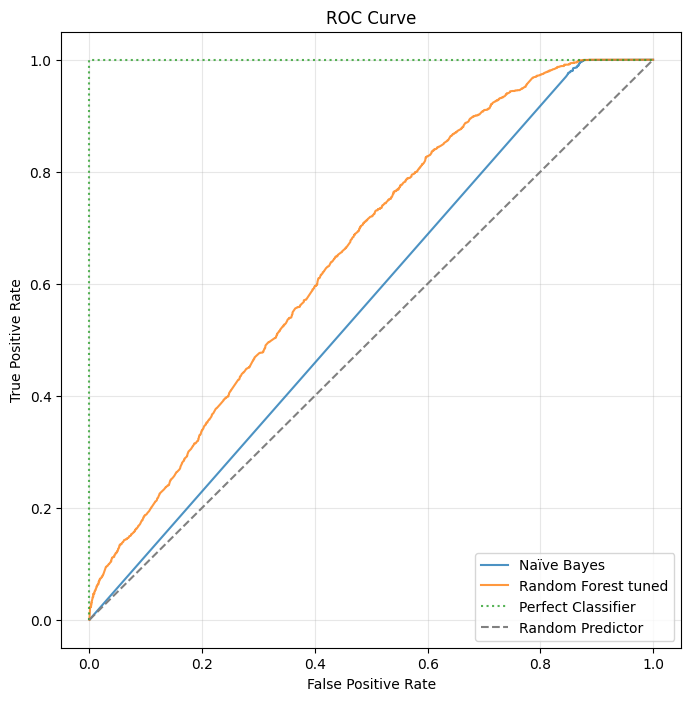

In [7]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(8, 8))


fpr, tpr, thresholds = roc_curve(y_test, p_nbc_test)
ax.plot(fpr, tpr, label="Naïve Bayes", alpha=0.8)


fpr, tpr, thresholds = roc_curve(y_test, p_rf_hyp_test)
ax.plot(fpr, tpr, label="Random Forest tuned", alpha=0.8)


ax.plot([0, 0, 1], [0, 1, 1], label="Perfect Classifier", linestyle=":", alpha=0.8)

ax.plot([0, 1], [0, 1], color="grey", linestyle="--", label="Random Predictor")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend()
ax.grid(alpha=.3)

Text(0.5, 1.0, 'Most Common')

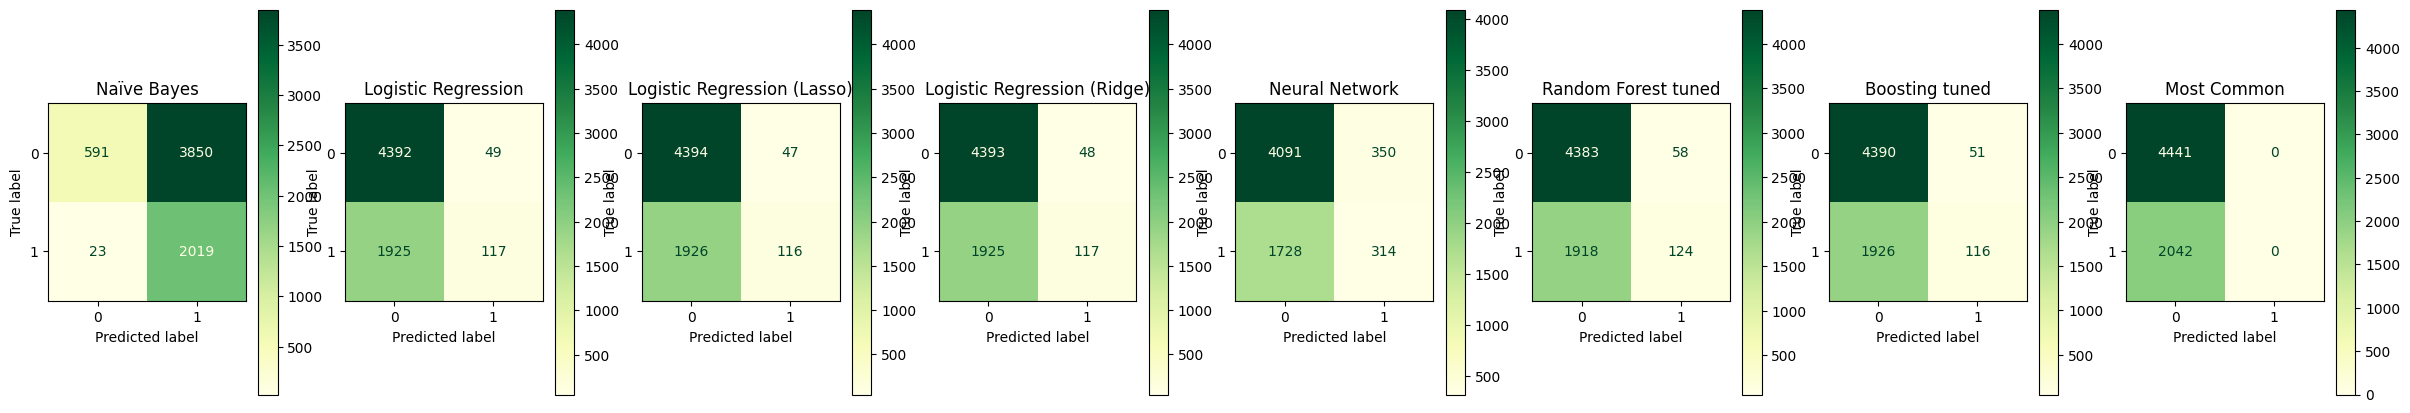

In [19]:
from sklearn.metrics import confusion_matrix

cm_bayes = confusion_matrix(y_test, y_pred_test_bayes)
cm_mc = confusion_matrix(y_test, y_pred_test_mc)
cm_logreg = confusion_matrix(y_test, y_pred_test_lrc)
cm_lasso = confusion_matrix(y_test, y_pred_test_lrc_lasso)
cm_ridge = confusion_matrix(y_test, y_pred_test_lrc_ridge)
cm_neural = confusion_matrix(y_test, y_pred_test_neuron)
cm_rf_hyp = confusion_matrix(y_test, y_pred_test_rf_hyp)
cm_boosting_hyp = confusion_matrix(y_test, y_pred_test_boosting_hyp)

from sklearn.metrics import ConfusionMatrixDisplay
fig, ax = plt.subplots(1, 8, figsize=(30, 5))


ConfusionMatrixDisplay(cm_bayes).plot(ax=ax[0], cmap=plt.cm.YlGn)
ax[0].set_title("Naïve Bayes")


ConfusionMatrixDisplay(cm_logreg).plot(ax=ax[1], cmap=plt.cm.YlGn)
ax[1].set_title("Logistic Regression")


ConfusionMatrixDisplay(cm_lasso).plot(ax=ax[2], cmap=plt.cm.YlGn)
ax[2].set_title("Logistic Regression (Lasso)")


ConfusionMatrixDisplay(cm_ridge).plot(ax=ax[3], cmap=plt.cm.YlGn)
ax[3].set_title("Logistic Regression (Ridge)")


ConfusionMatrixDisplay(cm_neural).plot(ax=ax[4], cmap=plt.cm.YlGn)
ax[4].set_title("Neural Network")

ConfusionMatrixDisplay(cm_rf_hyp).plot(ax=ax[5], cmap=plt.cm.YlGn)
ax[5].set_title("Random Forest tuned")


ConfusionMatrixDisplay(cm_boosting_hyp).plot(ax=ax[6], cmap=plt.cm.YlGn)
ax[6].set_title("Boosting tuned")


ConfusionMatrixDisplay(cm_mc).plot(ax=ax[7], cmap=plt.cm.YlGn)
ax[7].set_title("Most Common")


Text(0.5, 1.0, 'Boosting tuned')

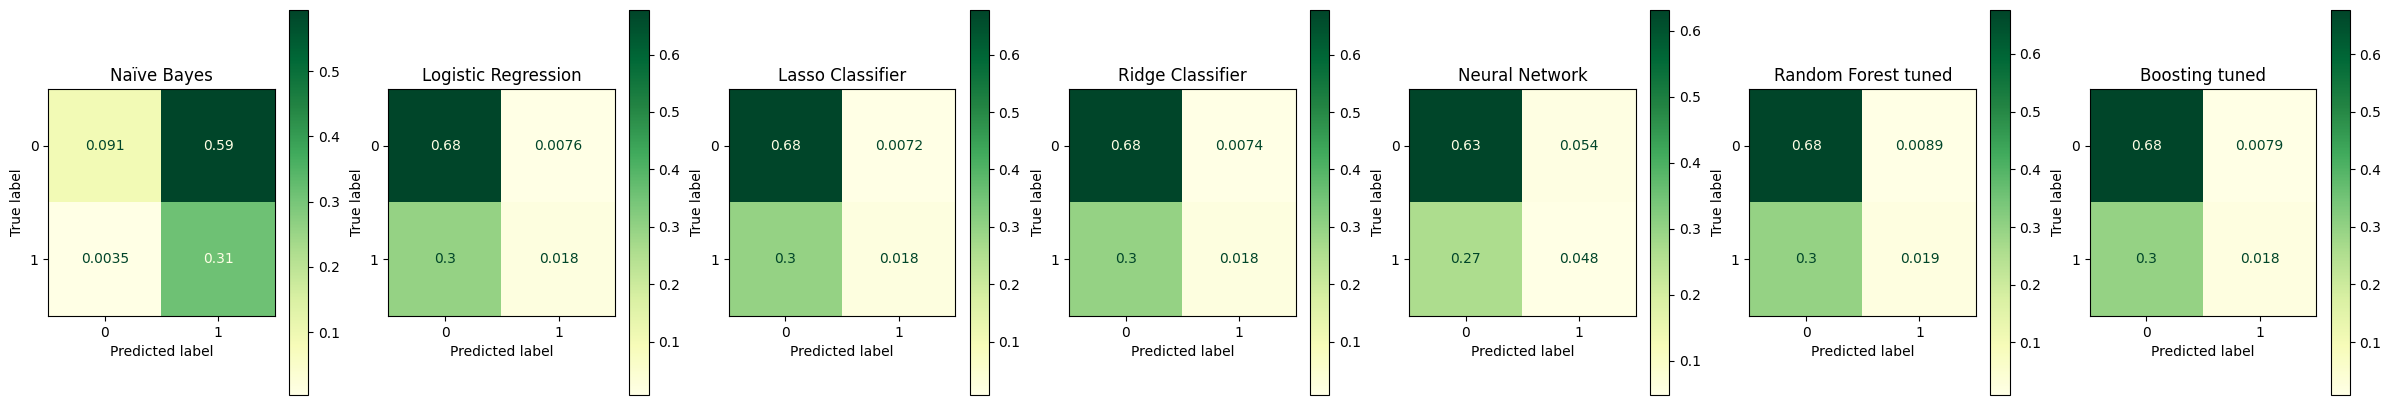

In [20]:
fig, ax = plt.subplots(1, 7, figsize=(30, 5))


ConfusionMatrixDisplay.from_estimator(
    nbc, X_test, y_test,
    normalize='all',      
    cmap=plt.cm.YlGn,
    ax=ax[0]
)
ax[0].set_title("Naïve Bayes")

ConfusionMatrixDisplay.from_estimator(
    lrc, X_test, y_test,
    normalize='all',     
    cmap=plt.cm.YlGn,
    ax=ax[1]
)
ax[1].set_title("Logistic Regression")



ConfusionMatrixDisplay.from_estimator(
    lrc_lasso, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[2]
)
ax[2].set_title("Lasso Classifier")


ConfusionMatrixDisplay.from_estimator(
    lrc_ridge, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[3]
)
ax[3].set_title("Ridge Classifier")


ConfusionMatrixDisplay.from_estimator(
    nnet, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[4]
)
ax[4].set_title("Neural Network")

ConfusionMatrixDisplay.from_estimator(
    search, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[5]
)
ax[5].set_title("Random Forest tuned")


ConfusionMatrixDisplay.from_estimator(
    search_boosting, X_test, y_test,
    normalize='all',
    cmap=plt.cm.YlGn,
    ax=ax[6]
)
ax[6].set_title("Boosting tuned")